In [9]:
import numpy as np
import matplotlib.pyplot as plt
# so I finally use a graphic primitive
from matplotlib.patches import Arc

# this is dangerous: extra dependencies!!!!
# sudo apt install cm-super
# sudo apt install dvipng
plt.rcParams['text.usetex'] = True

In [23]:
x,y = 5,5
print("$\\frac{" + str(x) + "}{" + str(y) +"}$")

$\frac{5}{5}$


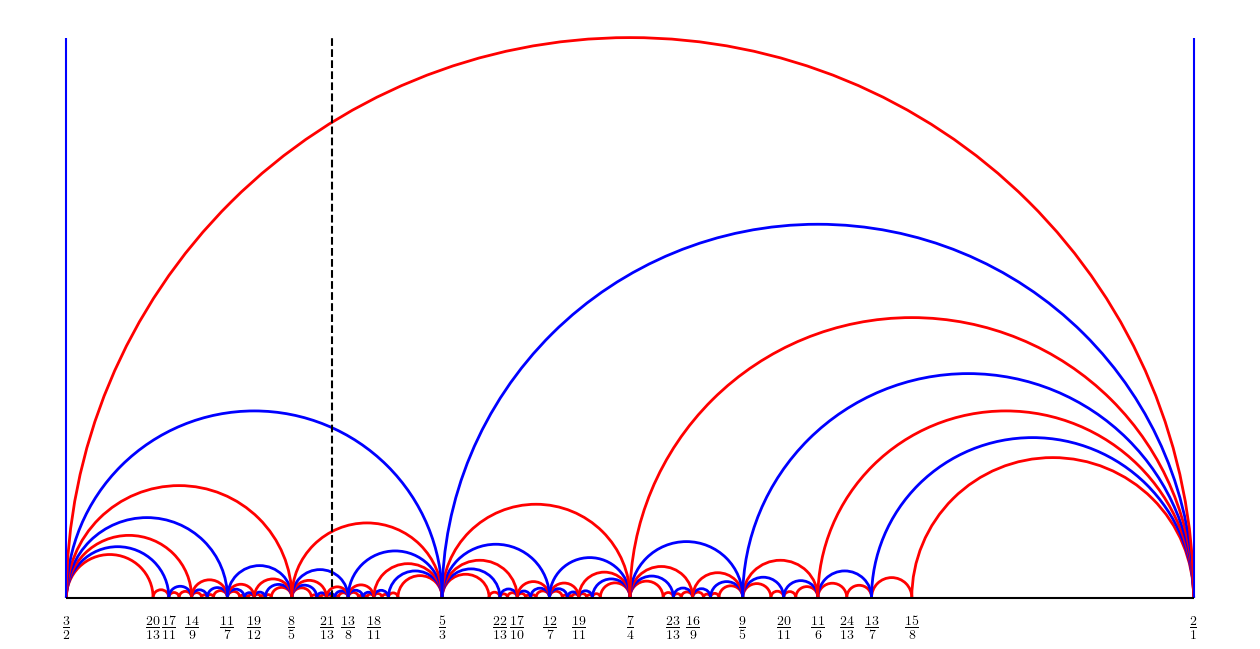

In [52]:
def F(n):
    if n == 0:
         return np.array([[3,2], [2,1]]).astype(int)
    #F_n-1 is not a valid variable name
    F_n_1 = F(n-1)
    F_n = np.zeros((2*F_n_1.shape[0]-1,2), dtype=int)
    F_n[::2,] = F_n_1
    F_n[1::2,] = F_n_1[:-1] + F_n_1[1:]
    return F_n


fig, ax = plt.subplots()
fig.set_size_inches(16,8)
ax.axis('off')


cols = 'rb'
depth = 6
pts = F(depth)
F_n =np.copy(pts)

for k in range(depth+1):
    fracs = F_n[:,0]/F_n[:,1]
    
    diams = fracs[1:] - fracs[:-1] 
    centres = .5*(fracs[1:] + fracs[:-1])

    color = cols[k % len(cols)]
    for x,d in zip(centres, diams):
        gg = Arc((x, 0), d, d, 
                  angle=0, theta1=0, theta2=180, 
                  color=color, lw=2)
        ax.add_patch(gg)
        
    #this looks dumb now I accidentally deleted it :(
    F_n = F_n[::2]
           
for pt in pts: 
    x,y = pt  
    if y > 13: continue
        
    label = f"$\\frac{{{x}}}{{{y}}}$"
    ax.annotate(label, # this is the text
                 (x/y, 0), # this is the point to label
                 textcoords="offset points", # how to position the text
                 xytext=(0,-25), 
                 fontsize = 14,
                 ha='center') 

a,b = pts[[0,-1]].T[0]/pts[[0,-1]].T[1]

plt.vlines([a,b],ymin=0,ymax=.5*(b-a),color='b')
plt.hlines([0],xmin=a,xmax=b,color='k')

phi = .5*(1 + np.sqrt(5))
plt.vlines([phi],ymin=0,ymax=.5*(b-a),
           color='k', linestyle="dashed")

plt.savefig('golden2.png')

In [53]:
pwd

'/home/macbuse/FAREY_DIAGRAM'

---

## Standard Ford circles with curvatures in $\mathbb{H}$

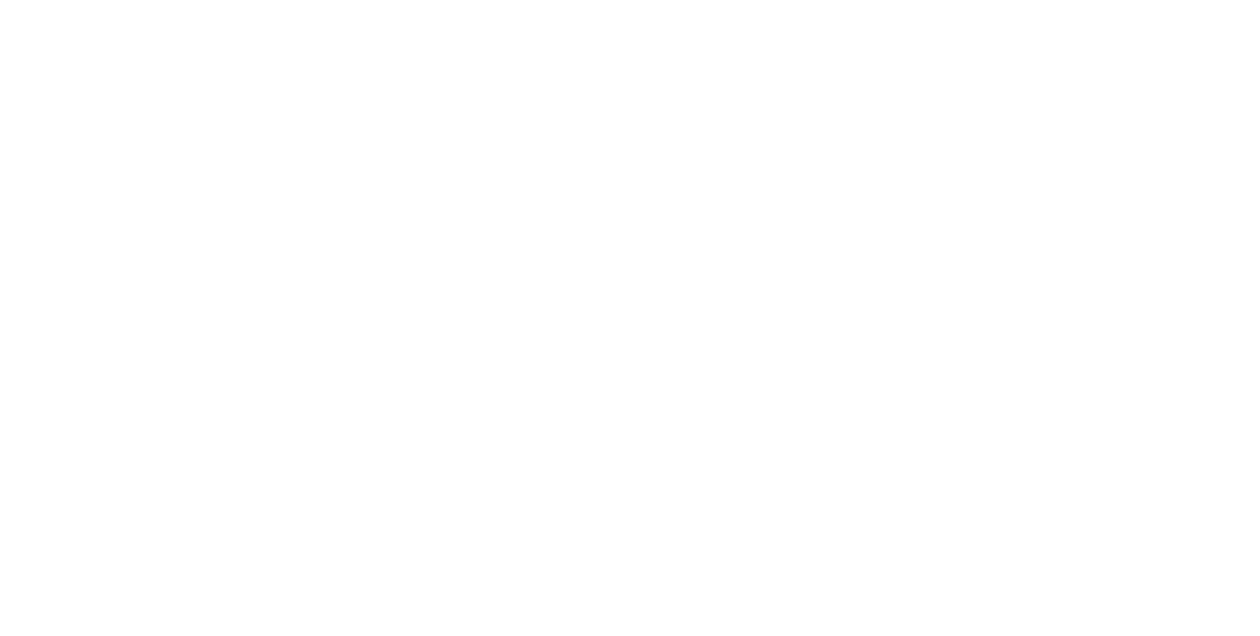

<Figure size 640x480 with 0 Axes>

In [26]:
def farey(n):
    F_n = np.array([[0,1], [1,1]])
    for _ in range(n):
        tmp = np.zeros((2*F_n.shape[0]-1, 2),dtype=int)
        # copy F_n in 
        tmp[::2,] = F_n
        # add medians in
        tmp[1::2,] = F_n[:-1] + F_n[1:]
        F_n = tmp
    return F_n

# see preamble for setup
plt.rcParams['text.usetex'] = True

fig, ax = plt.subplots()
fig.set_size_inches(16,8)
ax.axis('equal')
ax.axis('off')


T = np.linspace(0,2*np.pi, 40)
circle = np.exp(1J*T)/2

plt.show()
plt.savefig('golden2.png')


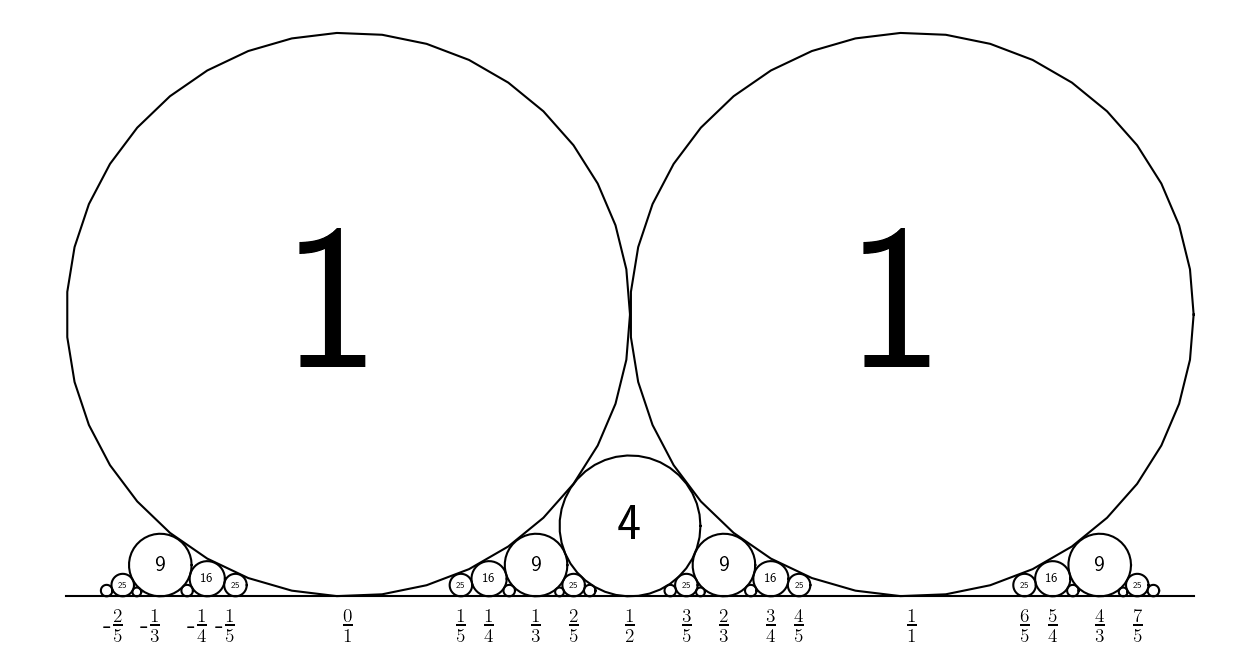

In [41]:
def farey(n):
    F_n = np.array([[0,1], [1,1]])
    for _ in range(n):
        tmp = np.zeros((2*F_n.shape[0]-1, 2),dtype=int)
        # copy F_n in 
        tmp[::2,] = F_n
        # add medians in
        tmp[1::2,] = F_n[:-1] + F_n[1:]
        F_n = tmp
    return F_n

# see preamble for setup
plt.rcParams['text.usetex'] = True

fig, ax = plt.subplots()
fig.set_size_inches(16,8)
ax.axis('equal')
ax.axis('off')


T = np.linspace(0,2*np.pi, 40)
circle = np.exp(1J*T)/2

FF = list(farey(4))

# 
PP1 = [ (n + d, d) for n,d in FF if 0 < n/d <.5]
PP1.extend([ (n - d, d) for n,d in FF if .5 < n/d < 1 ])

FF.extend(PP1)

for q in FF:
    numerator, denominator = q
    
    r = 1/denominator**2
    center = numerator/denominator + .5*r*1J
    ford_circle  = r*circle + center
    
    plt.plot(ford_circle.real , 
             ford_circle.imag ,'k');


    # add a label for the curvature
    if denominator < 6:
        ax.annotate(
            str(denominator**2), #label text
            xy=(center.real, center.imag), 
            xytext=(0,0),
            textcoords='offset points', 
            ha='center', va='center',
            fontsize=int(150/denominator**2)
        )
        
        if numerator < 0:
            label = r"-$\frac{{{}}}{{{}}}$".format(-numerator,denominator)
            ff = -.018
        else:
            label = r"$\frac{{{}}}{{{}}}$".format(numerator,denominator)
            ff = 0
    
            
        ax.annotate(label,
             xy=(center.real + ff, -0.05), 
             xytext=(0,0),
             textcoords='offset points', 
             ha='center', va='center',
             fontsize=20
                )
   
plt.plot([-0.5,1.5],[0,0],'k');
#need this to see the fractions
plt.plot([0],[-.01],'k');


plt.savefig('ford_circles.png')
plt.savefig('ford_circles.svg')

---

# Standard Farey  diagram in $\mathbb{D}$

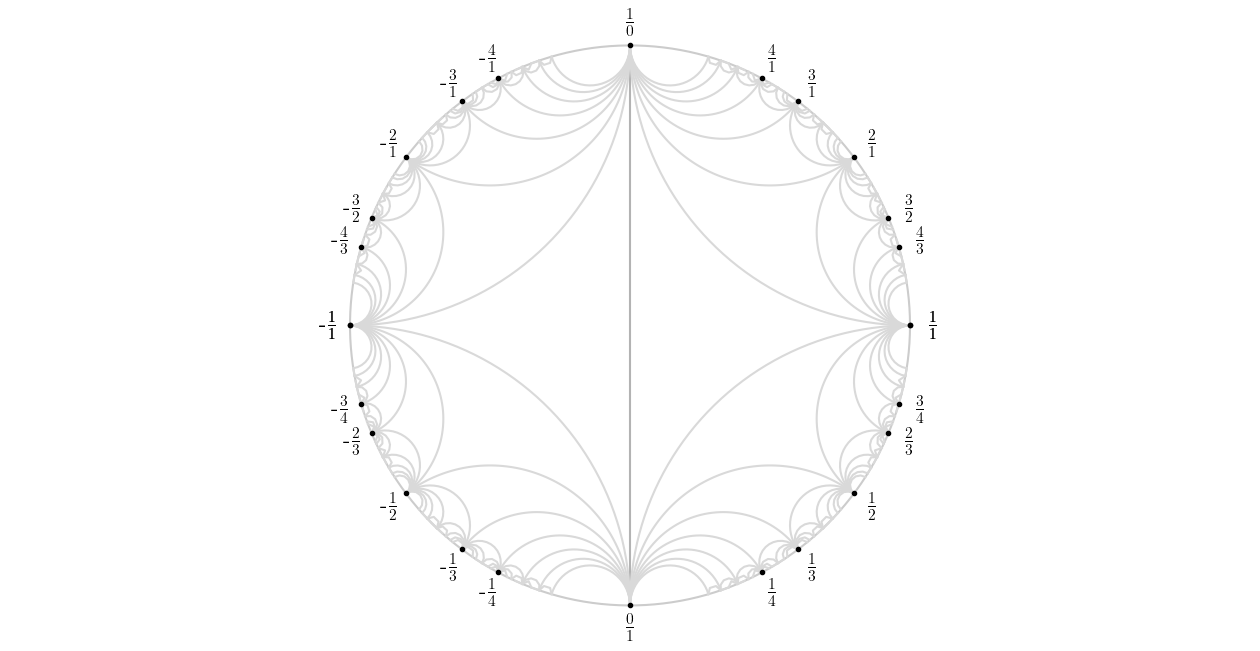

In [4]:
def farey(n):
    # start with a seed to do subdivisions on
    # this one is slightly modded
    F_n = np.array([[-1,1],[0,1], [1,1]],dtype=int)
    for _ in range(n):
        tmp = np.zeros((2*F_n.shape[0]-1, 2),dtype=int)
        # copy F_n in 
        tmp[::2,] = F_n
        # add medians in
        tmp[1::2,] = F_n[:-1] + F_n[1:]
        F_n = tmp
    return F_n

def cayley(z):
    ''' map the upper half plane to the unit disk
        -1->-1, 1->1 and 0->-i'''
    return 1J*(z-1J)/(z+1J)

def seg2arc(a,b):
    '''a,b points on the unit circle
    return the center, radius and angle
    for the Poincaré geodesic from a to b
    '''
    y = abs(a-b)/2
    dd = 1/np.sqrt(1 - y**2)
    r = y*dd
    return dd*(a+b)/abs(a+b), r, np.arccos(y)

# housekeeping
fig, ax = plt.subplots()
fig.set_size_inches(16,8)
ax.axis('equal')
ax.axis('off')

# draw the unit circle and a diameter
T = np.linspace(0,2*np.pi , 200)
C = np.exp(1J*T)
ax.plot(C.real,C.imag,'.8')
ax.plot([0,0], [1,-1],'.7')


QQ = farey(6).T
#map fractions to the circle
Z =  cayley(QQ[0]/QQ[1]) 

while len(Z) > 2:
    for a, b in zip(Z, Z[1:]):
        delta = abs(a - b)
        # don't display small arcs
        if  delta < .01 : continue
        cc, r, theta = seg2arc(a, b)
        T = np.linspace(-theta, theta, int(100*delta))
        arc = -r*np.exp(1J*T)*(cc/abs(cc)) + cc
        ax.plot( arc.real, arc.imag,'0.85')
        arc = -arc
        ax.plot(arc.real, arc.imag,'0.85')   
    # now go to the previous level 
    # by deleting every other element
    Z = Z[::2]

#this is the label string
rlabel = r"{}$\frac{{{}}}{{{}}}$"
for q in QQ.T:
    numerator, denominator = q
    # no big denominators
    if denominator > 4: continue
    z = cayley(numerator/denominator)
    
    cx, cy = 1.08*z.real, 1.08*z.imag
    
    #I don'y know if this is clearer but it works
    sign, numerator = '-' if numerator < 0 else '', abs(numerator)
    labels = [ (rlabel.format(sign, numerator,denominator), cx,cy),
               (rlabel.format(sign, denominator,numerator), cx,-cy)]
    for label,x,y in labels:
        ax.annotate(label,
                    xy=(x, y), 
                    xytext=(0,0),
                    textcoords='offset points', ha='center', va='center',
                    fontsize=16
                    )

    plt.plot([z.real],[z.imag],'ok', markersize=3)
    plt.plot([z.real],[-z.imag],'ok', markersize=3)
    

plt.savefig('pivot.png')

In [73]:
(r"{}$\frac{{{}}}{{{}}}$".format(sign, numerator,denominator), cx,cy)

('-$\\frac{1}{1}$', -1.08, -0.0)

In [66]:
! ./.g

[main 2b878e3] misc
 5 files changed, 599 insertions(+), 908 deletions(-)
 create mode 100644 .ipynb_checkpoints/README-checkpoint.md
 rewrite farey_diagram.png (98%)
Enumerating objects: 12, done.
Counting objects: 100% (12/12), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (7/7), 225.21 KiB | 3.52 MiB/s, done.
Total 7 (delta 4), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (4/4), completed with 4 local objects.
To https://github.com/macbuse/FAREY_DIAGRAM.git
   075ff18..2b878e3  main -> main


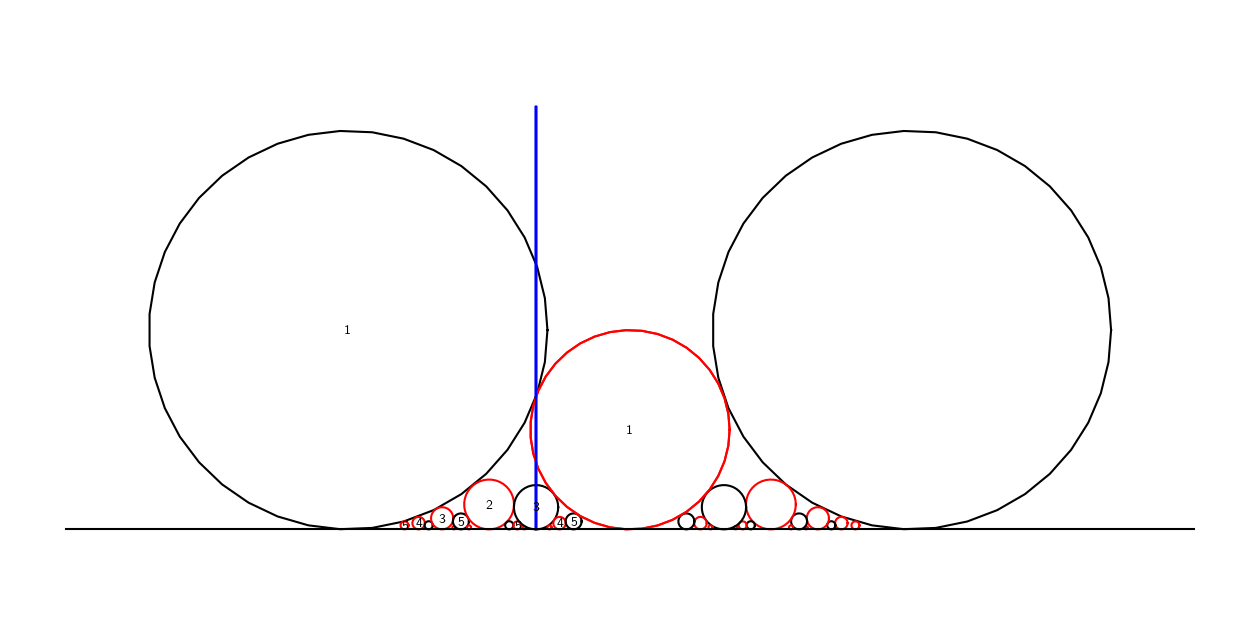

In [2]:
def farey(n):
    F_n = np.array([[0,1], [1,1]])
    for k in range(n):
        tmp = np.zeros((2*F_n.shape[0]-1, 2))
        # copy F_n in 
        tmp[::2,] = F_n
        # add medians in
        tmp[1::2,] = F_n[:-1] + F_n[1:]
        F_n = tmp
    return F_n

QQ = farey(4)

fig, ax = plt.subplots()
fig.set_size_inches(16,8)
ax.axis('equal')
ax.axis('off')

T = np.linspace(0,2*np.pi, 40)
motif = np.exp(1J*T)/2
SCALE = 200
data = []
for vv in QQ[:]:
    col = 'k'
    stroke = "#000000"
    r = np.sqrt(2)/vv[1]**2
    if vv[0] % 2 == 1 : 
        r /= 2
        col = 'r'
        stroke = "#FF0000"
    mm  = r*motif 
    cx = vv[0]/vv[1]
    cy = .5*r

    plt.plot(mm.real + cx, 
             mm.imag + cy ,col);

    if vv[1] < 6:
        ax.annotate(
            str(int(vv[1])),
            xy=(cx, cy), 
            xytext=(3, -5),
            textcoords='offset points', ha='right', va='bottom',
            #bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5),
            #arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0')
        )
    
    plt.plot(mm.real + 2 -  vv[0]/vv[1], 
             mm.imag + .5*r,col);

    plt.plot([2/3]*2,[0,1.5],'b')

    r *= SCALE/2
    cx = SCALE*cx + 2*SCALE
    cy *= SCALE

    gg = f'<circle cx="{cx:.2f}" cy="{cy:.2f}" r="{r:.2f}" fill ="none" stroke = "{stroke}"/>'
    data.append(gg)
    cx = 4*SCALE - cx
    data.append(gg)
    
plt.plot([-1,3],[0,0],'k');
plt.savefig('farey_mod.png')

ss = '''<svg viewBox="0 0 1000 1000" xmlns="http://www.w3.org/2000/svg">
  {}
</svg>'''.format('\n'.join(data))
with open('pp.svg','w') as fp:
    fp.write(ss)

In [3]:
3**2 + 2*2**2

17

In [7]:
A = np.array([1,1,2,3],dtype=int).reshape(2,2)
np.linalg.det(A)

1.0

In [8]:
A

array([[1, 1],
       [2, 3]])

In [9]:
A[0] -= A[1]
A

array([[-1, -2],
       [ 2,  3]])

In [10]:
(1J + 1)*(-2J + 3)

(5+1j)

In [ ]:
5 + 